# ATC ASR &mdash; Exploratory Data Analysis

Reads the cached `processed/` snapshot (no re-download) and decodes audio through
`soundfile` (no torchcodec).

In [1]:
import io
import random
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from datasets import Audio

# Locate the sibling Datasets folder relative to wherever this notebook runs.
here = Path.cwd()
root = next((p for p in [here, *here.parents] if (p / "Datasets" / "data.py").exists()), None)
if root is None:
    raise FileNotFoundError("Could not find the Datasets folder; open this inside the ATC project.")
sys.path.insert(0, str(root / "Datasets"))

from data import corpora
from normalize import normalize

data = corpora()
SOURCES = ("atcosim", "uwb_atcc", "atco2_1h")
data

DatasetDict({
    train: Dataset({
        features: ['audio', 'text_raw', 'text_norm', 'source', 'split_orig', 'ood'],
        num_rows: 17982
    })
    validation: Dataset({
        features: ['audio', 'text_raw', 'text_norm', 'source', 'split_orig', 'ood'],
        num_rows: 947
    })
    test_indomain: Dataset({
        features: ['audio', 'text_raw', 'text_norm', 'source', 'split_orig', 'ood'],
        num_rows: 4723
    })
    test_ood: Dataset({
        features: ['audio', 'text_raw', 'text_norm', 'source', 'split_orig', 'ood'],
        num_rows: 871
    })
})

## Text frame

A tidy table of every utterance's split, source, normalized text, and word count.
All text-side analysis below is vectorized off this one frame.

In [2]:
frames = [
    pd.DataFrame({"split": name, "source": s["source"], "text": s["text_norm"]})
    for name, s in data.items()
]
df = pd.concat(frames, ignore_index=True)
df["n_words"] = df["text"].str.split().str.len().fillna(0).astype(int)
df.head()

,split,source,text,n_words
0,train,uwb_atcc,air berlin two nine eight victor direct hotel ...,10
1,train,atcosim,alitalia three six nine is identified,6
2,train,uwb_atcc,flight level three four zero finn air eight ze...,11
3,train,atcosim,swiss air six five two zero call rhein on one ...,16
4,train,uwb_atcc,easy six eight kilo papa vectoring terminated ...,12


## Data Inspection

Sets expectations for the in-domain vs. out-of-distribution comparison and shows
how much real-radio audio there is relative to clean simulation.

In [3]:
counts = df.groupby(["split", "source"]).size().unstack(fill_value=0)
counts

source,atco2_1h,atcosim,uwb_atcc
split,,,
test_indomain,0,1901,2822
test_ood,871,0,0
train,0,7235,10747
validation,0,403,544


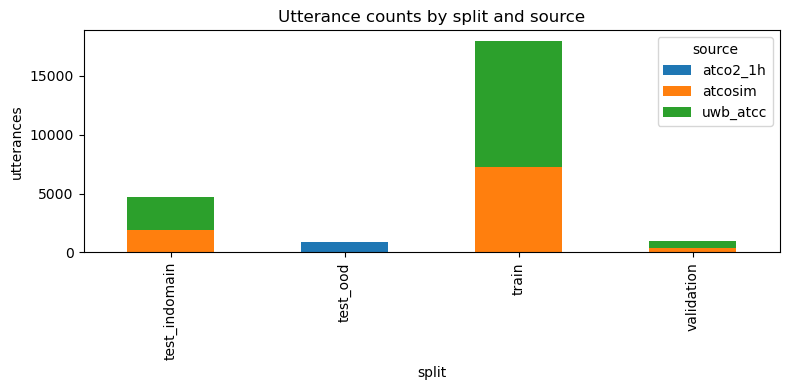

In [4]:
counts.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("utterances")
plt.title("Utterance counts by split and source")
plt.tight_layout()
plt.show()

## How long are the clips, and do any exceed Whisper's 30s window?

Whisper encodes 30-second windows. Clips beyond that are truncated unless chunked.
Clips clustered very short waste compute on padding. Durations and native sample
rates are read from headers (decode-free) on a seeded sample per split.

In [5]:
def durations(split, n=2000):
    raw = split.cast_column("audio", Audio(decode=False))
    total = len(raw)
    idx = random.Random(0).sample(range(total), min(n, total))
    rows = []
    for i in idx:
        row = raw[i]
        a = row["audio"]
        info = sf.info(a["path"] or io.BytesIO(a["bytes"]))
        rows.append((row["source"], info.frames / info.samplerate, info.samplerate))
    return pd.DataFrame(rows, columns=["source", "seconds", "sample_rate"])

dur = pd.concat([durations(s) for s in data.values()], ignore_index=True)
dur.groupby("source")["seconds"].describe()[["mean", "50%", "max"]]

,mean,50%,max
source,,,
atco2_1h,4.078762,3.75,15.27
atcosim,3.906006,3.75,19.24
uwb_atcc,3.242482,2.98,8.00


fraction of clips over 30s
source
atco2_1h    0.0
atcosim     0.0
uwb_atcc    0.0


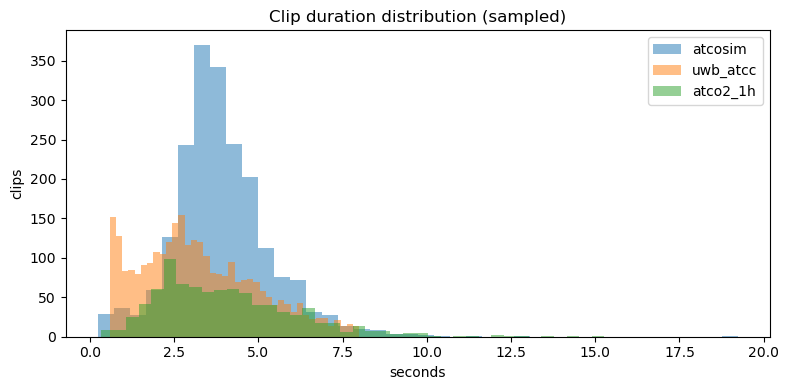

In [6]:
over = dur.assign(long=dur["seconds"] > 30).groupby("source")["long"].mean()
print("fraction of clips over 30s")
print(over.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for src in SOURCES:
    ax.hist(dur.loc[dur.source == src, "seconds"], bins=40, alpha=0.5, label=src)
ax.set_xlabel("seconds")
ax.set_ylabel("clips")
ax.legend()
ax.set_title("Clip duration distribution (sampled)")
plt.tight_layout()
plt.show()

## What are the native sample rates?

Close-talk simulation sits at a higher rate than VHF radio. Upsampling 8 kHz
radio to 16 kHz adds no real high-frequency content, which is a structural reason
the OOD set is harder. It might be worth quantifying rather than assuming.

In [7]:
dur.groupby("source")["sample_rate"].agg(["min", "max", lambda s: s.mode().iloc[0]]).rename(
    columns={"<lambda_0>": "mode"})

,min,max,mode
source,,,
atco2_1h,16000,16000,16000
atcosim,32000,32000,32000
uwb_atcc,8000,8000,8000


## How long are transcripts, and are any empty?

An empty reference breaks WER (zero-length denominator) and is dead weight in
training. This count protects the eval math before we build the scorer.

In [8]:
empties = int((df["n_words"] == 0).sum())
print("empty transcripts:", empties)
df.groupby("source")["n_words"].describe()[["mean", "50%", "min", "max"]]

empty transcripts: 0


,mean,50%,min,max
source,,,,
atco2_1h,12.428243,11.0,1.0,40.0
atcosim,11.257994,11.0,1.0,71.0
uwb_atcc,10.042018,10.0,1.0,32.0


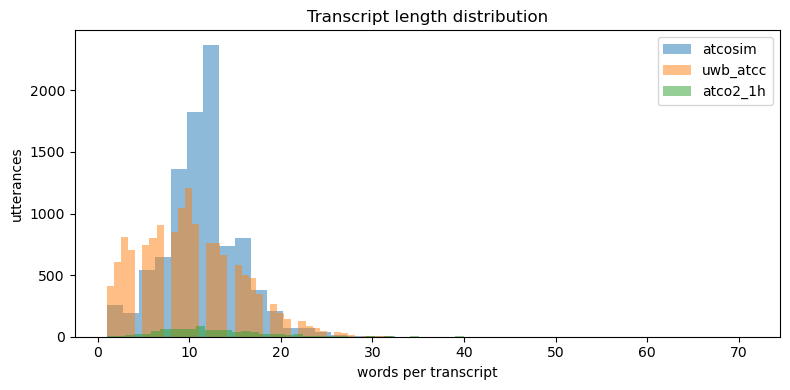

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for src in SOURCES:
    ax.hist(df.loc[df.source == src, "n_words"], bins=40, alpha=0.5, label=src)
ax.set_xlabel("words per transcript")
ax.set_ylabel("utterances")
ax.legend()
ax.set_title("Transcript length distribution")
plt.tight_layout()
plt.show()

## What does the vocabulary look like?

ATC is a constrained domain. The size and shape of the vocabulary, and the most
frequent tokens, show how much of the signal is digits, phonetics, and commands.

In [10]:
tokens = df.assign(tok=df["text"].str.split()).explode("tok").dropna(subset=["tok"])
vocab = tokens["tok"].value_counts()
print("vocabulary size:", int(vocab.shape[0]))
vocab.head(25)

vocabulary size: 2525


tok
one          19757
three        17231
zero         15898
two          14181
five         10874
four         10278
seven         7665
six           6883
nine          6141
level         6115
eight         5954
flight        5090
contact       4739
to            4378
radar         3702
good          3591
point         2789
lufthansa     2775
bye           2695
csa           2524
air           2521
climb         2412
descend       2013
praha         1984
runway        1674
Name: count, dtype: int64

## How do callsigns appear and do they differ by source?

This is direct design input for the callsign-accuracy metric. ICAO phonetic words
(the alphabet) signal registration-style callsigns. An operator name followed by a
digit string signals airline-style callsigns. If the share differs sharply by
source, the metric has to handle both forms.

In [11]:
PHONETIC = {
    "alpha", "bravo", "charlie", "delta", "echo", "foxtrot", "golf", "hotel",
    "india", "juliet", "kilo", "lima", "mike", "november", "oscar", "papa",
    "quebec", "romeo", "sierra", "tango", "uniform", "victor", "whiskey",
    "xray", "yankee", "zulu",
}
share = tokens.groupby("source")["tok"].apply(lambda s: float(s.isin(PHONETIC).mean()))
print("share of tokens that are ICAO phonetic words")
print(share.round(3).to_string())

share of tokens that are ICAO phonetic words
source
atco2_1h    0.155
atcosim     0.029
uwb_atcc    0.061


In [12]:
lead = df[df["n_words"] > 0].assign(first=df.loc[df["n_words"] > 0, "text"].str.split().str[0])
for src in SOURCES:
    top = lead.loc[lead.source == src, "first"].value_counts().head(8)
    print(f"{src} - most common leading token")
    print(top.to_string(), "\n")

atcosim - most common leading token
first
lufthansa    1372
alitalia      921
air           559
sabena        384
delta         301
swiss         286
aero          269
roger         262 

uwb_atcc - most common leading token
first
csa          1268
lufthansa     869
one           832
praha         819
three         290
air           259
two           239
sky           227 

atco2_1h - most common leading token
first
hotel      170
oscar       43
runway      24
one         23
roger       21
tower       20
heli        18
cleared     17 



## Clean vs. noisy audio look like?

A spectrogram of one simulation clip beside one real-radio clip makes the domain
shift concrete with bandwidth limit and noise floor are exactly what fine-tuning has
to overcome on the OOD set.

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:8233: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


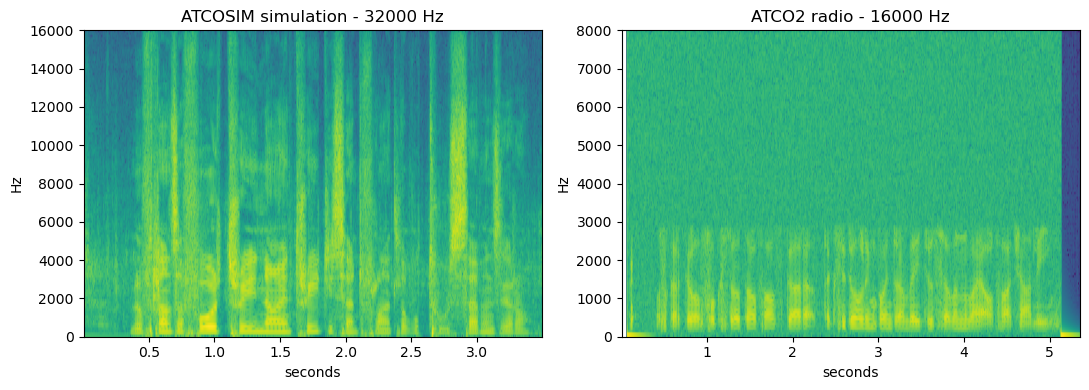

In [13]:
def waveform(item):
    src = io.BytesIO(item["bytes"]) if item.get("bytes") else item["path"]
    audio, sr = sf.read(src)
    if audio.ndim > 1:
        audio = audio[:, 0]
    return audio, sr

clean = data["test_indomain"].cast_column("audio", Audio(decode=False))
noisy = data["test_ood"].cast_column("audio", Audio(decode=False))
i_clean = next(i for i, s in enumerate(clean["source"]) if s == "atcosim")
clean_audio, clean_sr = waveform(clean[i_clean]["audio"])
noisy_audio, noisy_sr = waveform(noisy[0]["audio"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].specgram(clean_audio, Fs=clean_sr)
axes[0].set_title(f"ATCOSIM simulation - {clean_sr} Hz")
axes[1].specgram(noisy_audio, Fs=noisy_sr)
axes[1].set_title(f"ATCO2 radio - {noisy_sr} Hz")
for ax in axes:
    ax.set_xlabel("seconds")
    ax.set_ylabel("Hz")
plt.tight_layout()
plt.show()

## Transcript leakage between train and the in-domain test set?

We carved validation off training ourselves, so that is clean. But the upstream
in-domain test split could share identical readbacks with train, which would
inflate in-domain scores. Short readbacks recur legitimately, so longer overlaps
are the ones that matter.

In [14]:
train_text = set(df.loc[df.split == "train", "text"])
test_text = set(df.loc[df.split == "test_indomain", "text"])
shared = train_text & test_text
print("unique transcripts shared between train and in-domain test:", len(shared))
print("longest overlaps (more concerning than short readbacks):")
for t in sorted(shared, key=lambda s: -len(s))[:8]:
    print(" ", repr(t))

unique transcripts shared between train and in-domain test: 335
longest overlaps (more concerning than short readbacks):
  'transwede one zero seven good afternoon radar contact maintain flight level three three zero trasadingen st prex'
  'air malta four five zero identified route ageri zurich east nelli maintain flight level three two zero'
  'lufthansa four seven zero zero climb to flight level three four zero own navigation st prex'
  'jetcom one three three further climb clearance contact radar one three three point four bye'
  'air inter three two zero papa hotel contact reims on one three four point four bye bye'
  'air inter three two zero papa hotel contact reims one three four point four good bye'
  'jetcom one three three for further climb zurich one three three point four good bye'
  'swiss air four eight eight contact rhein control on one three two point four bye'
